In [51]:
# IMPORTIAMO TUTTO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# IMMIGRAZIONE TRA DATI E CRONACA

## INTRODUZIONE: 

Il presente progetto nasce con lo scopo di mettere in relazione i dati forniti dall'Istat, relativi ai residenti di tutti i comuni italiani, con alcuni articoli del quotidiano *La Repubblica*. Nello specifico, il tema principale sarà quello dell'**immigrazione**, con un focus ristretto sui residenti sul territorio italiano provenienti da 6 "paesi target" (che verranno definiti successivamente).


### OBIETTIVI:

1. Fare osservazioni di natura statistico-distribuzionale, indagando il **numero** e la **collocazione sul territorio** degli abitanti provenienti dai suddetti paesi (analisi quantitativa di variazioni cronologiche, geografiche e di genere).
2. Indagare eventuali correlazioni tra la **visibilità mediatica** delle comunità straniere rispetto all'**effettiva presenza sul territorio** (confronto con gli articoli de *La Repubblica*).
3. Intercettare l'esistenza di **associazioni terminologiche** tra comunità straniere e parole con differenti connotazioni (positive, negative o neutre), rintracciate negli articoli incentrati sull'immigrazione.

# I DATI ISTAT SULLA CITTADINANZA
Per portare a compimento il primo obiettivo, ci avvaliamo dei dati ISTAT relativi alla cittadinanza. Essi sono in formato .csv e sono denominati Dati_cittadinanza_*anno*. Tali dati contengono le informazioni demografiche per singolo comune e ripartizione territoriale dal 2002 al 2025. 

### IMPORTIAMO I DATI
Per prima cosa importiamo i dati che ci interessano, facendo attenzione a:
1. type del separatore (qualora non fosse ",") ;

2. type del dato (i numeri che iniziano con 0 potrebbero essere trattati come interi, con conseguente perdita del valore originario corretto).

Il seguente codice restituisce un dataframe, denominato `cittadinanza_totale`, utile per illustrare visivamente il contenuto del dataset.

In [52]:
# LEGGIAMO I DATI SULLA CITTADINANZA
# Occorre adoperare un ciclo che scorra tutti i csv in Dati_RCS
# Utilizziamo os per leggere tutti i dati all'interno di una cartella

path = "dati/istat/Dati_RCS"
lista_df = []

# os.listdir() usa come input una cartella e restituisce semplicemente una lista dei contenuti di quella cartella
# Usiamo un ciclo for che scorre ogni file di tale lista e lo assegna alla variabile nome_file
for nome_file in os.listdir(path): 
    
    # Controlliamo che il file riguardi la cittadinanza
    if "cittadinanza" in nome_file:
        full_path = os.path.join(path, nome_file) 
        # os.path.join() viene usato per unire il NOME del file con la cartella a cui appartiene
        # il risultato viene salvato nella variabile "full_path"
        
        # Leggiamo "full_path", creato precedentemente e creiamo un dataframe tramite pandas
        temp_df = pd.read_csv(full_path, sep=';', dtype={'Codice Istat': str})
        # temp_df è una tabella temporanea che a ogni iterazione viene "svuotata" e nuovamente "riempita" per ogni file

        # Prendiamo la tabella appena letta (temp_df) e aggiungiamola alla lista creata all'inizio.
        lista_df.append(temp_df)
        # alla fine del ciclo for, ogni tabella temporanea sarà aggiunta alla lista

# Concateniamo ogni singola tabella salvata nella lista e uniamo tutto in un unico grande DataFrame
cittadinanza_totale = pd.concat(lista_df, ignore_index=True) 
# ignore_index=True serve per riordinare gli indici a 0 a N (elimina quelli originali)
cittadinanza_totale

,Anno,Codice Istat,Denominazione,Codice stato di cittadinanza,Stato di cittadinanza,Zona,Continente,Maschi,Femmine,Totale
0,2002,001001,Agliè,100,Italia,Unione Europea,Europa,1205,1325,2530
1,2002,001001,Agliè,201,Albania,Europa Centro-Orientale,Europa,2,0,2
2,2002,001001,Agliè,314,Cina,Asia Orientale,Asia,1,0,1
3,2002,001001,Agliè,215,Francia,Unione Europea,Europa,0,1,1
4,2002,001001,Agliè,436,Marocco,Africa Settentrionale,Africa,4,0,4
...,...,...,...,...,...,...,...,...,...,...
5471442,2025,IT,Italia,619,Venezuela,America Centro-Meridionale,America,6533,10448,16981
5471443,2025,IT,Italia,353,Vietnam,Asia Orientale,Asia,521,1268,1789
5471444,2025,IT,Italia,354,Yemen,Asia Occidentale,Asia,213,134,347
5471445,2025,IT,Italia,464,Zambia,Africa Orientale,Africa,116,137,253


# ALCUNE STATISTICHE SULLE CITTADINANZE STRANIERE
## CONTEGGIO CITTADINI STRANIERI (2013-2019)
Abbiamo creato un codice che restituisce il numero di abitanti in Italia per ciascuna delle seguenti sei nazionalità:
1. ALBANESI
2. CINESI
3. MAROCCHINI
4. RUMENI
5. TUNISINI
6. UCRAINI

Il codice restituisce il dataframe `df_istat`, strutturato con l'anno come indice, che mostra il totale dei cittadini per ogni comunità tra quelle selezionate e per ciascun anno, preservando al contempo la disaggregazione per genere (Maschi e Femmine). 

Abbiamo escluso le colonne del dataframe originario `cittadinanza_totale` denominate "Codice Istat", "Denominazione", "Codice stato di cittadinanza", "Zona" e "Continente". Rispetto a `cittadinanza_totale`, infine, il nuovo dataframe include solo l'arco temporale che va dal 2013 al 2019. La scelta di considerare solo i dati relativi all'arco cronologico 2013-2019 è motivata dal fatto che, successivamente, opereremo un confronto quantitativo e qualitativo rispetto agli articoli de *La Repubblica*, datati, appunto, dal 2013 al 2019. 

Al momento del conteggio, per evitare duplicazioni (dovute alla presenza nel dataset di aggregati provinciali, regionali, di area geografica), è stato necessario applicare un filtro selettivo che isolasse esclusivamente i dati con un "Codice Istat" composto da 6 caratteri, identificativo esclusivamente dei comuni.

In [53]:
path = "dati/istat/Dati_RCS"
nazionalità_target = ["Albania", "Cina", "Marocco", "Romania", "Tunisia", "Ucraina"]
pattern_anni = r"201[3-9]" # le parentesi quadre delimitano un INSIEME di caratteri
                           # il trattino denota un intervallo: [3-9] fa match con tutti i caratteri da 3 a 9

dati_istat = []

# Con os.listdir(path) viene aperta la cartella e viene restituita una lista di tutti i file in essa contenuti
for nome_file in os.listdir(path):
# Il ciclo entra nel file solo se il nome contiene "cittadinanza" e se l'anno nel nome del file è compreso tra il 2013 e il 2019
    if "cittadinanza" in nome_file and re.search(pattern_anni, nome_file):
        # re.search(pattern, string) cerca la prima occorrenza che fa match con pattern, non per forza all'inizio di tale stringa
       
        # Estraiamo l'anno dal nome del file: in seguito ci servirà per creare una nuova colonna "anno"
        anno = re.search(pattern_anni, nome_file).group()
        # "group" è una funzione specifica degli oggetti match e serve a estrarre il testo
        # quando si usa re.search(pattern, string), infatti, Python non restituisce direttamente la stringa trovata, ma un "oggetto di corrispondenza" (Match Object)

        # Usiamo os.path.join per unire il nome del file con la cartella cui appartiene
        full_path = os.path.join(path, nome_file)
        # Leggiamo "full_path" e creiamo un dataframe tramite pandas
        df_temp = pd.read_csv(full_path, sep=';', dtype={'Codice Istat': str})
        
        # PRIMO FILTRO: filtriamo solo le righe con Codice Istat lungo esattamente 6 caratteri
        # Questo esclude "IT", i codici regionali e conta solo i COMUNI, per evitare di sommare dati in più
        df_comuni = df_temp[df_temp["Codice Istat"].str.len() == 6].copy()
        # teniamo solo le righe in cui la lunghezza del Codice Istat è uguale a 6
        # .copy() serve ad assicurarci che venga creata una tabella nuova indipendente per non generare errore
        
        # SECONDO FILTRO: filtriamo per le nazionalità target
        df_filtrato = df_comuni[df_comuni["Stato di cittadinanza"].isin(nazionalità_target)]
        # .isin è un metodo di pandas che prende in input una LISTA di valori che vogliamo prendere in considerazione
        
        # Sommiamo i valori per ogni anno
        somma_per_anno = df_filtrato.groupby("Stato di cittadinanza")[["Maschi", "Femmine", "Totale"]].sum().reset_index()
        # .groupby().sum() raggruppa per Stato di cittadinanza e calcola la somma di Maschi, Femmine e Totale per quel determinato anno
        # .reset_index() serve a far tornare "Stato di cittadinanza" una colonna normale e non un indice grafico

        # Creiamo una nuova colonna anno (numero intero)
        somma_per_anno["Anno"] = int(anno)
        
        # Aggiungiamo ogni dataframe di ogni anno alla lista iniziale
        dati_istat.append(somma_per_anno)

# Concateniamo tutti i dataframe relativi a tutti gli anni considerati
df_istat = pd.concat(dati_istat, ignore_index=True) # ignore_index serve a risistemare gli indici quando usiamo concat
# Indicizziamo per anno
df_istat = df_istat.set_index("Anno") # con .set_index spostiamo la colonna "anno" come indice
df_istat

,Stato di cittadinanza,Maschi,Femmine,Totale
Anno,,,,
2013,Albania,252065,231066,483131
2013,Cina,112749,110656,223405
2013,Marocco,248844,208046,456890
2013,Romania,432447,564079,996526
2013,Tunisia,60164,37610,97774
2013,Ucraina,42127,161468,203595
2014,Albania,253592,234533,488125
2014,Cina,119444,117670,237114
2014,Marocco,254206,215259,469465


## EVOLUZIONE DEMOGRAFICA DELLE SEI COMUNITÀ TARGET 
Dopo aver creato il dataframe `df_istat` e ottenuto i dati quantitativi, abbiamo deciso di illustrarne l'evoluzione demografica mediante grafici. La visualizzazione attraverso i barplot, infatti, ci consente di cogliere immediatamente come la presenza di alcune comunità straniere sia in alcuni casi aumentata, e in altri diminuita in modo più o meno significativo. I grafici rappresentano la distribuzione numerica totale, senza distinzioni di genere; un'analisi sociologica (anche se solo quantitiva) di questo tipo sarà operata in seguito.

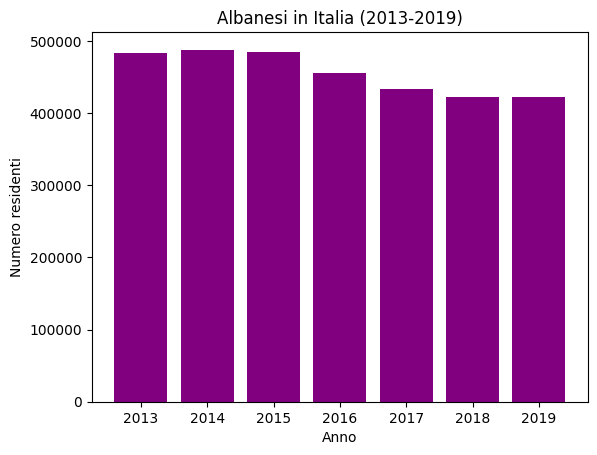

In [54]:
# Creiamo un barplot per osservare la variazione numerica di ogni nazionalità negli anni
anni = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
cittadini_albanesi = df_istat[df_istat["Stato di cittadinanza"] == "Albania"]["Totale"]

fig, ax = plt.subplots()
ax.bar(anni, cittadini_albanesi, color="purple")
ax.set_title("Albanesi in Italia (2013-2019)")
ax.set_xlabel("Anno")
ax.set_ylabel("Numero residenti")

plt.show()

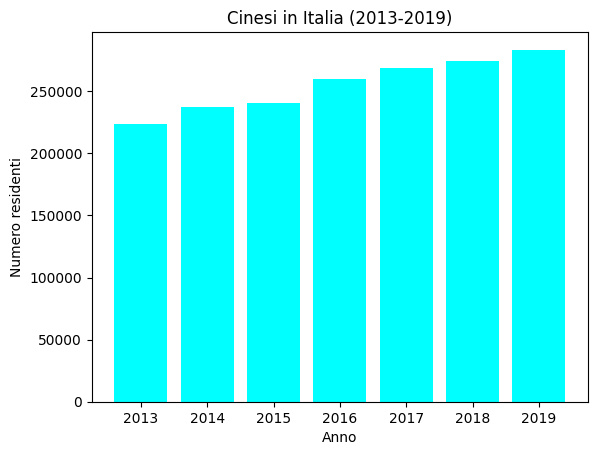

In [55]:
anni = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
cittadini_cinesi = df_istat[df_istat["Stato di cittadinanza"] == "Cina"]["Totale"]

fig, ax = plt.subplots()
ax.bar(anni, cittadini_cinesi, color="cyan")
ax.set_title("Cinesi in Italia (2013-2019)")
ax.set_xlabel("Anno")
ax.set_ylabel("Numero residenti")

plt.show()

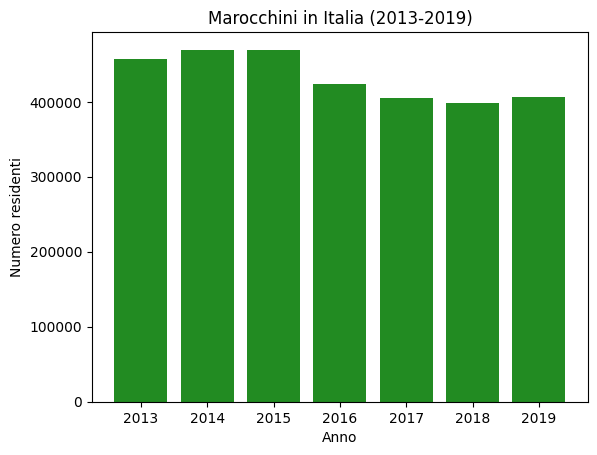

In [56]:
anni = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
cittadini_marocchini = df_istat[df_istat["Stato di cittadinanza"] == "Marocco"]["Totale"]

fig, ax = plt.subplots()
ax.bar(anni, cittadini_marocchini, color="forestgreen")
ax.set_title("Marocchini in Italia (2013-2019)")
ax.set_xlabel("Anno")
ax.set_ylabel("Numero residenti")

plt.show()

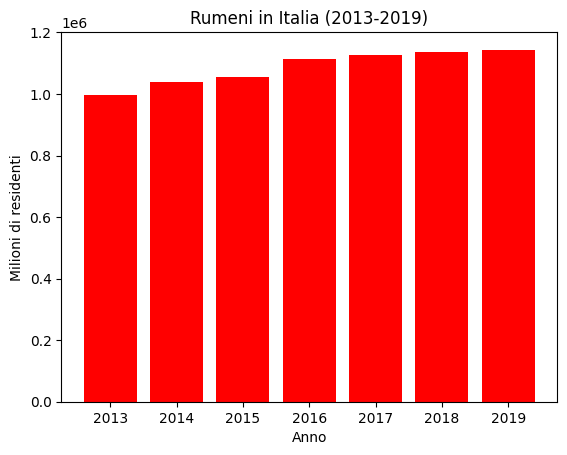

In [57]:
anni = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
cittadini_rumeni = df_istat[df_istat["Stato di cittadinanza"] == "Romania"]["Totale"]

fig, ax = plt.subplots()
ax.bar(anni, cittadini_rumeni, color="red")
ax.set_title("Rumeni in Italia (2013-2019)")
ax.set_xlabel("Anno")
ax.set_ylabel("Milioni di residenti")

plt.show()

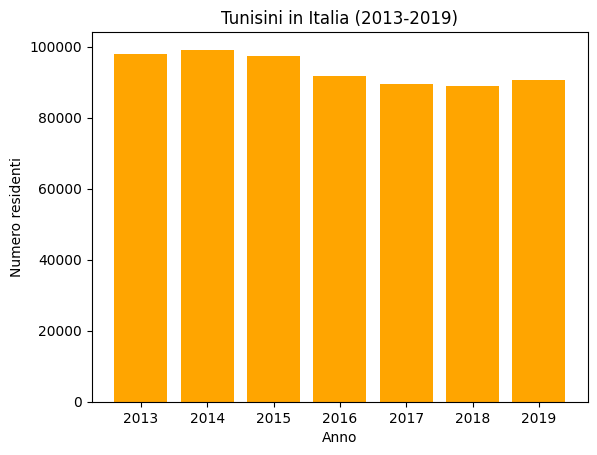

In [58]:
anni = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
cittadini_tunisini = df_istat[df_istat["Stato di cittadinanza"] == "Tunisia"]["Totale"]

fig, ax = plt.subplots()
ax.bar(anni, cittadini_tunisini, color="orange")
ax.set_title("Tunisini in Italia (2013-2019)")
ax.set_xlabel("Anno")
ax.set_ylabel("Numero residenti")

plt.show()

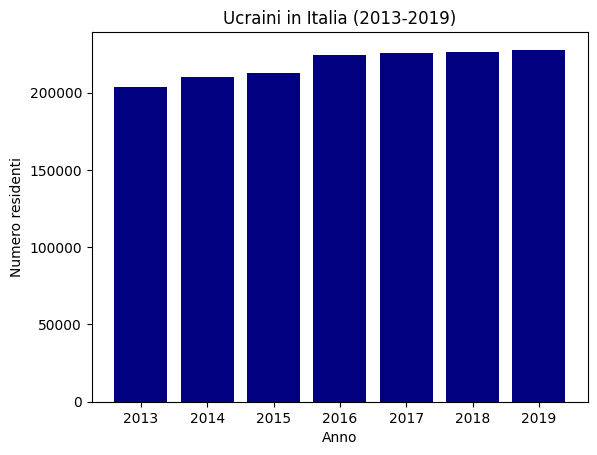

In [59]:
anni = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
cittadini_ucraini = df_istat[df_istat["Stato di cittadinanza"] == "Ucraina"]["Totale"]

fig, ax = plt.subplots()
ax.bar(anni, cittadini_ucraini, color="navy")
ax.set_title("Ucraini in Italia (2013-2019)")
ax.set_xlabel("Anno")
ax.set_ylabel("Numero residenti")

plt.show()

Accorpiamo ora questi dati all'interno di un unico grafico, al fine di confrontare le variazioni demografiche di ciascuna comunità e cogliere differenza di tendenza tra le medesime. Per farlo, scegliamo seaborn come libreria:

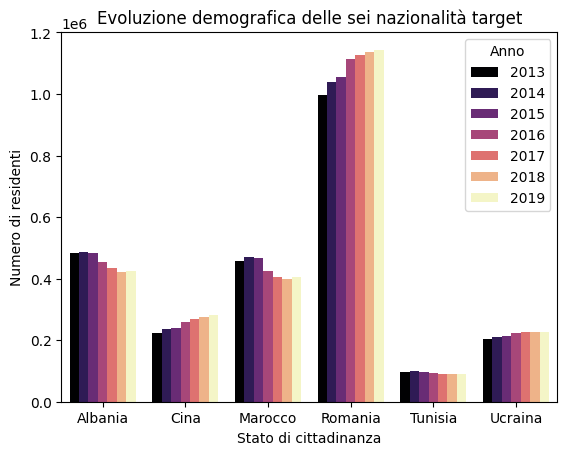

In [60]:
# Riportiamo l'indice "Anno" a colonna, così Seaborn può usarlo come hue
barplot_anni = df_istat.reset_index()

# Creiamo un barplot raggruppato: una barra per ogni anno dentro ciascuna cittadinanza
sns.barplot(data=barplot_anni, x="Stato di cittadinanza", y="Totale", hue="Anno", palette="magma")
# x="Stato di cittadinanza" raggruppa i blocchi per nazionalità
# hue="Anno" crea le 7 barre colorate diverse all'interno di ogni blocco

plt.title("Evoluzione demografica delle sei nazionalità target")
plt.xlabel("Stato di cittadinanza")
plt.ylabel("Numero di residenti")
plt.legend(title="Anno")

plt.show()

Una prima osservazione interessante, che emerge chiaramente del grafico, è che non ci sia un trend condiviso dalle 6 comunità target: se da un lato sussiste una decrescita demografica per Albania e Marocco, dall'altro i numeri delle comunità cinese e rumena aumentano. Le comunità tunisina e ucraina, invece, mostrano una variazione numerica quasi trascurabile.

### Media "cronologica" dei residenti stranieri
Per ottenere un unico valore di riferimento per ogni nazionalità, calcoliamo la media aritmetica dei residenti stranieri nell'arco cronologico dal 2013 al 2019, mantenendo comunque la divisione tra `"Maschi"`, `"Femmine"` e `"Totale"`.

In [61]:
media_nazionalità = df_istat.groupby("Stato di cittadinanza")[["Maschi", "Femmine", "Totale"]].mean().astype(int)
# utilizziamo .astype(int) per visualizzare un numero intero e non decimale
media_nazionalità

,Maschi,Femmine,Totale
Stato di cittadinanza,,,
Albania,234764,220967,455731
Cina,128443,126906,255349
Marocco,232403,200262,432665
Romania,466028,621528,1087556
Tunisia,57862,35731,93593
Ucraina,46817,171823,218640


### Visualizziamo i dati ottenuti 

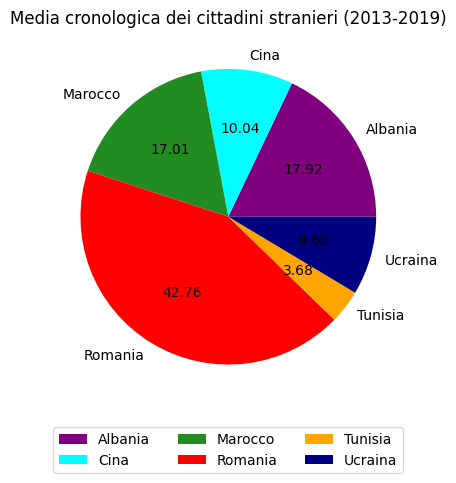

In [62]:
# Togliamo "Stato di cittadinanza" come indice per includerlo nel grafico
dati = media_nazionalità.reset_index() 

comunità = dati["Stato di cittadinanza"]
popolazione = dati["Totale"]
colori = ["purple", "cyan", "forestgreen", "red", "orange", "navy"]

fig, ax = plt.subplots()
ax.pie(popolazione, labels=comunità, colors=colori, autopct="%.2f")
ax.set_title("Media cronologica dei cittadini stranieri (2013-2019)")
ax.legend(bbox_to_anchor=(0.5, -0.05), loc="upper center", ncol=3)

plt.show()

Osservando il grafico si può cogliere immediatamente che la comunità rumena, rappresentata in rosso, è di gran lunga quella numericamente preponderante: coprendo quasi il 43% del campione, è seguita da quelle albanese e marocchina (entrambe circa 17%), cinese, ucraina e, infine, tunisina (sotto al 4%).

### Discrepanza di genere?

Dal dataframe `media_nazionalità` sono emerse delle discrepanze tra il numero di cittadini **maschi** e quello delle cittadine **femmine** per due comunità specifiche: **ucraina** e **tunisina**.

Nello specifico si riscontra che:
- nel primo caso sono le donne ad essere più numerose: circa il 75% dell'intera popolazione ucraina in Italia;
- nel secondo caso è la presenza maschile ad essere superiore, più del doppio di quella femminile.

Visualizziamo tale differenza:

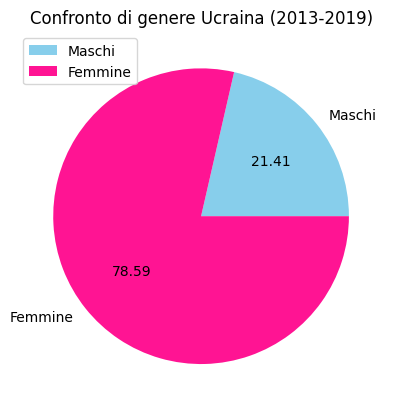

In [63]:
dati_genere_ucraina = media_nazionalità.reset_index() 
dati_genere_ucraina = media_nazionalità.loc["Ucraina"]

categorie = ["Maschi", "Femmine"]
popolazione = dati_genere_ucraina[["Maschi", "Femmine"]]
colori = ["skyblue", "deeppink"]

fig, ax = plt.subplots()
ax.pie(popolazione, labels=categorie, colors=colori, autopct="%.2f")
ax.set_title("Confronto di genere Ucraina (2013-2019)")
ax.legend()

plt.show()

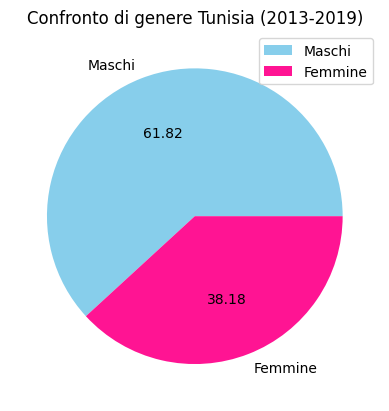

In [64]:
dati_genere_tunisia = media_nazionalità.reset_index() 
dati_genere_tunisia = media_nazionalità.loc["Tunisia"]

categorie = ["Maschi", "Femmine"]
popolazione = dati_genere_tunisia[["Maschi", "Femmine"]]
colori = ["skyblue", "deeppink"]

fig, ax = plt.subplots()
ax.pie(popolazione, labels=categorie, colors=colori, autopct="%.2f")
ax.set_title("Confronto di genere Tunisia (2013-2019)")
ax.legend()

plt.show()

Esula dalle nostre possibilità condurre una ricerca approfondita di carattere sociologico, che sia in grado di motivare le discrepanze osservate. Tuttavia, ci sembra comunque rilevante riportare i dati emersi in questa sede, anche senza avanzare ipotesi relative alla spiegazione del fenomeno.

## DISTRIBUZIONE GEOGRAFICA DELLE SEI NAZIONALITÀ TARGET
Dopo aver condotto le prime osservazioni, abbiamo deciso di procedere con un'analisi di carattere territoriale-distribuzionale, la quale rientra sempre nel primo obiettivo del presente lavoro. Prendendo in input gli stessi file .csv studiati in precedenza, abbiamo creato il dataframe `df_istat_denominazione`, che fornisce i dati relativi alla distribuzione geografica delle sei comunità straniere nella penisola. Le divisioni geografiche cui abbiamo fatto riferimento sono quelle riportate nei file .csv Dati_cittadinanza_*anno*, sotto la colonna `"Denominazione"`: 
1. Nord-Ovest
2. Nord-Est
3. Centro
4. Sud 
5. Isole 

Tali aree corrispondono, rispettivamente, ai Codici Istat: 1, 2, 3, 4, 5. 

In [65]:
path = "dati/istat/Dati_RCS"
nazionalità_target = ["Ucraina", "Tunisia", "Romania", "Cina", "Marocco", "Albania"]
pattern_anni = r"201[3-9]" # le parentesi quadre delimitano un INSIEME di caratteri
                           # il trattino denota un intervallo: [3-9] fa match con tutti i caratteri da 3 a 9

dati_istat = []

# Con os.listdir(path) viene aperta la cartella e viene restituita una lista di tutti i file in essa contenuti
for nome_file in os.listdir(path):
# Il ciclo entra nel file solo se il nome contiene "cittadinanza" e se l'anno nel nome del file è compreso tra il 2013 e il 2019
    if "cittadinanza" in nome_file and re.search(pattern_anni, nome_file):
        # re.search(pattern, string) cerca la prima occorrenza che fa match con pattern, non per forza all'inizio di tale stringa
       
        # Estraiamo l'anno dal nome del file > in seguito ci servirà per creare una nuova colonna "anno"
        anno = re.search(pattern_anni, nome_file).group()
        # "group" è una funzione specifica degli oggetti match e serve a estrarre il testo
        # quando usi re.search(pattern, testo), infatti, Python non restituisce direttamente la stringa trovata, ma un "oggetto di corrispondenza" (Match Object)

        # Usiamo os.path.join per unire il nome del file con la cartella cui appartiene
        full_path = os.path.join(path, nome_file)
        # Leggiamo "full_path" e creiamo un dataframe tramite pandas
        df_temp = pd.read_csv(full_path, sep=';', dtype={'Codice Istat': str})
        
        # PRIMO FILTRO: filtriamo solo le righe con Codice Istat lungo esattamente 1 carattere
        df_comuni = df_temp[df_temp["Codice Istat"].str.len() == 1].copy()
        # .copy() serve ad assicurarci che venga creata una tabella nuova indipendente per non generare errore
        
        # SECONDO FILTRO: filtriamo per le nazionalità target
        df_filtrato = df_comuni[df_comuni["Stato di cittadinanza"].isin(nazionalità_target)]
        # .isin è un metodo di pandas che prende in input una LISTA di valori che vogliamo prendere in considerazione
        
        # Sommiamo i valori per ogni anno e includiamo la colonna Denominazione (ripartizioni penisola)
        somma_annuale = df_filtrato.groupby(["Stato di cittadinanza", "Denominazione"])[["Maschi", "Femmine", "Totale"]].sum().reset_index()
        # .groupby().sum() raggruppa per Stato di cittadinanza e Denominazione calcola la somma di Maschi, Femmine e Totale per quel determinato anno
        # .reset_index() serve a far tornare "Stato di cittadinanza" una colonna normale e non un indice grafico

        # Creiamo una nuova colonna anno > numero intero
        somma_annuale["Anno"] = int(anno)
        
        # Aggiungiamo ogni dataframe di ogni anno alla lista iniziale
        dati_istat.append(somma_annuale)

# Concateniamo tutti i dataframe relativi a tutti gli anni considerati
df_istat_denominazione = pd.concat(dati_istat, ignore_index=True) # ignore_index serve a risistemare gli indici quando usiamo concat (se non usassimo concat, la funzione adeguata sarebbe index=False)
# Indicizziamo per anno
df_istat_denominazione = df_istat_denominazione.set_index("Anno") # con .set_index spostiamo la colonna "anno" come indice
df_istat_denominazione

,Stato di cittadinanza,Denominazione,Maschi,Femmine,Totale
Anno,,,,,
2013,Albania,Centro,67464,61192,128656
2013,Albania,Isole,4388,3786,8174
2013,Albania,Nord-est,65845,61272,127117
2013,Albania,Nord-ovest,88810,81618,170428
2013,Albania,Sud,25558,23198,48756
...,...,...,...,...,...
2019,Ucraina,Centro,9226,34205,43431
2019,Ucraina,Isole,782,3715,4497
2019,Ucraina,Nord-est,11999,45536,57535


### Accorpamento Nord-Ovest e Nord-Est

Al fine di ottenere una divisione maggiormente uniforme, accorpiamo i dati relativi alle due ripartizioni geografiche nord-est e nord-ovest in un'unica macroarea Nord, così da confrontare la distribuzione geografica tra **Nord**, **Centro**, **Sud** e **Isole**.

In [66]:
# Creiamo un dizionario per accorpare le macro-aree
accorpamento_aree = {
    "Nord-ovest": "Nord",
    "Nord-est": "Nord",
    "Centro": "Centro",
    "Sud": "Sud",
    "Isole": "Isole" 
}

# Creiamo una copia per non modificare il dataframe originale
df_nord_unito = df_istat_denominazione.copy()

# Sostituiamo i nomi delle aree usando il dizionario
df_nord_unito["Denominazione"] = df_nord_unito["Denominazione"].replace(accorpamento_aree)

# RAGGRUPPIAMO
df_divisioni_finali = df_nord_unito.groupby(["Anno", "Denominazione", "Stato di cittadinanza"])[["Maschi", "Femmine", "Totale"]].sum().reset_index()
# mettiamo insieme tutte le righe che hanno lo stesso anno, la stessa denominazione e lo stesso Stato di cittadinanza.
# per ogni gruppo identico appena trovato, prendiamo i valori numerici di maschi, femmine e totali e li sommiamo tra loro 
# in questo modo, poiché Nord-ovest e Nord-est sono stati rinominati "Nord", i loro dati vengono "fusi" per ogni riga di ogni anno
# chiaramente, i dati relativi alle altre ripartizioni geografiche rimangono inalterati

# indicizziamo per anno
df_divisioni_finali = df_divisioni_finali.set_index("Anno")
df_divisioni_finali

,Denominazione,Stato di cittadinanza,Maschi,Femmine,Totale
Anno,,,,,
2013,Centro,Albania,67464,61192,128656
2013,Centro,Cina,32353,30894,63247
2013,Centro,Marocco,34741,28680,63421
2013,Centro,Romania,134797,177869,312666
2013,Centro,Tunisia,9522,6284,15806
...,...,...,...,...,...
2019,Sud,Cina,13670,12508,26178
2019,Sud,Marocco,33754,22136,55890
2019,Sud,Romania,60082,86011,146093


### Media "cronologica" dei residenti stranieri per ripartizione geografica

Anche per il dataframe contenente le divisioni territoriali (`df_divisioni_finali`), calcoliamo la **media aritmetica** dei residenti stranieri nell'arco temporale 2013-2019, così da ottenere un unico valore di riferimento per ciascuna comunità nel dataframe `media_aree`.

In [67]:
media_aree = df_divisioni_finali.groupby(["Stato di cittadinanza", "Denominazione"])[["Maschi", "Femmine", "Totale"]].mean().astype(int)
media_aree = media_aree.reset_index()
media_aree 

,Stato di cittadinanza,Denominazione,Maschi,Femmine,Totale
0,Albania,Centro,62085,57998,120083
1,Albania,Isole,4638,4060,8698
2,Albania,Nord,143387,136190,279578
3,Albania,Sud,24652,22718,47371
4,Cina,Centro,38290,37420,75710
5,Cina,Isole,4988,4827,9815
6,Cina,Nord,72376,73018,145394
7,Cina,Sud,12788,11640,24428
8,Marocco,Centro,32986,28023,61009
9,Marocco,Isole,10905,7909,18814


### Visualizziamo i risultati ottenuti 

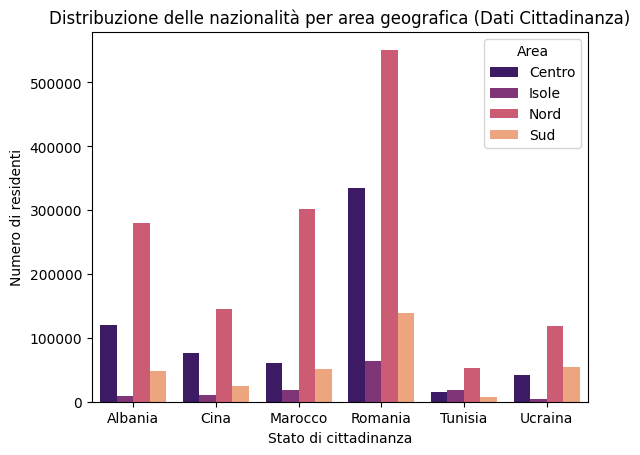

In [68]:
sns.barplot(data=media_aree, x="Stato di cittadinanza", y="Totale", hue="Denominazione", palette = "magma")

plt.title("Distribuzione delle nazionalità per area geografica (Dati Cittadinanza)")
plt.xlabel("Stato di cittadinanza")
plt.ylabel("Numero di residenti")
plt.legend(title="Area")

plt.show()

Come possiamo evincere dal grafico, la maggior parte dei residenti di ciascuna delle sei comunità target si trova nel **nord** della penisola, seguito dal centro (fatta eccezione per la comunità ucraina, la cui distribuzione è più concentrata al sud piuttosto che al centro), sud e isole. 

# IL DATASET REPUBBLICA

Dopo aver analizzato, da un punto di vista puramente statistico e demografico, i dati relativi ai cittadini stranieri residenti in Italia, abbiamo deciso di studiare in che misura e con quali modalità la stampa nazionale ne ha parlato nello stesso arco temporale. Per farlo, abbiamo utilizzato il dataset "repubblica.csv", contenente oltre 60.000 articoli pubblicati dal quotidiano *La Repubblica* tra il 2013 e il 2019.

In particolare, abbiamo cercato di verificare l’esistenza di una corrispondenza tra la reale presenza dei cittadini stranieri sul territorio italiano e lo spazio loro dedicato all’interno degli articoli di giornale. Ciò corrisponde al secondo obiettivo del presente lavoro.

La nostra ricerca si articola quindi su due livelli:

1. da una parte abbiamo condotto un conteggio delle **occorrenze**, che ci ha permesso di osservare con quale frequenza le sei comunità da noi selezionate vengano citate nei vari articoli;
2. dall'altra, abbiamo tentato analizzare la **narrazione** costruita attorno a queste comunità attraverso un’indagine di carattere lessicale (corrispondente al nostro terzo e ultimo obiettivo)

### IMPORTIAMO I DATI
Per prima cosa, importiamo i dati che ci interessano. Il seguente codice restituisce il dataframe `repubblica`, composto da tre colonne, quali titolo, corpo del testo, e url dell'articolo:

In [69]:
repubblica = pd.read_csv("dati/change-it/repubblica.csv")
repubblica.head()

,headline,full_text,url
0,"Commissione adozioni: ""Casi sospetti tra bimbi...",Nella lunga e complicata vicenda delle adozion...,NaN
1,"James Lovelock: ""Dieci anni fa ero certo che l...",L'ULTIMO REGALO DI JAMES LOVELOCK è un elisir ...,http://www.repubblica.it/ambiente/2016/10/02/n...
2,A Ezio Mauro il Premiolino 2017. Riconosciment...,MILANO - L'ex direttore di Repubblica Ezio Mau...,http://www.repubblica.it/cultura/2017/06/20/ne...
3,Ciampi ricoverato a Bolzano,BOLZANO - Il presidente emerito Carlo Azeglio ...,http://www.repubblica.it/politica/2014/07/11/n...
4,"Pordenone, ritrovati i tre ragazzi dispersi su...",ANDREIS (PORDENONE) - Paura e poi sollievo per...,http://www.repubblica.it/cronaca/2014/08/16/ne...


Creiamo la funzione di tokenizzazione `tokenizza`, la quale pulisce "full_text" e restituisce una lista di tokens.


In [70]:
# CREIAMO UNA FUNZIONE DI TOKENIZZAZIONE
def tokenizza(testo):
    # Gestiamo le maiuscole
    testo_pulito = str(testo).lower() # case sensitive
    
    # Usiamo una regex
    pattern = r"\w+"
    token = re.findall(pattern, testo_pulito)
    return token

print(tokenizza("Le cittadine ucraine vengono dall'Ucraina. Quelle franco-tunisine dalla Francia o dalla Tunisia."))

['le', 'cittadine', 'ucraine', 'vengono', 'dall', 'ucraina', 'quelle', 'franco', 'tunisine', 'dalla', 'francia', 'o', 'dalla', 'tunisia']


Creiamo una funzione `conta_frequenza`, che conta quante **occorrenze** di `varianti` (variabile in input che sostituiremo con `diz_nazionalità`) compaiono nel dataset tokenizzato. Questa funzione applica due filtri euristici specifici per le nazionalità: la disambiguazione tra Stato e persona (per il caso di "ucraina") e l'esclusione di parole fuorvianti che precedono il termine (es. "cucina cinese"):

In [ ]:
def conta_frequenza(lista_tokens, varianti):  
    # riceve una lista di parole già pulite (tokenizzate mediante la funzione precedente) 
    # e conta le occorrenze delle varianti.
    conteggio = 0
    preposizioni_stato = ["in", "da", "dall", "di", "l"] # filtro geopolitico
    parole_fuorvianti = {
        # Culinaria
        "cucina", "ricetta", "ristorante", "trattoria", "chef", "piatto", "sapore", 
        "tradizione", "degustazione", "menu", "couscous", "involtini", "rosticceria", "cibo",
        # Politica Estera e Geopolitica
        "presidente", "premier", "ministro", "governo", "parlamento", "elezioni", 
        "voto", "conflitto", "guerra", "invasione", "missili", "fronte", "esercito",
        # Sport e Spettacolo
        "nazionale", "calciatore", "giocatore", "attaccante", "campionato", "cultura", "lingua",
        "allenatore", "film", "regista", "attore", "attrice", "cantante", "festival",
        # Appellativi e Nomi Propri (Falsi positivi) 
        "signor", "signora", "don", "dottor", "francesca", "michele", 
        "antonio", "alessandro", "andrea", 
    }
    
    # Ciclo for
    for i in range(len(lista_tokens)):
        parola = lista_tokens[i]
    # invece di fare un ciclo sulle parole, lo facciamo sull'indice i
    # questo ci servirà in seguito per prendere in considerazione la parola precedente > (lista_tokens[i-1]) > EURISTICA
    
        # Controlliamo se la parola è nel dizionario "parole_fuorvianti"
        if parola in varianti:
            # Ma prima gestiamo il caso ambiguo della variante "ucraina" > può essere sia "donna proveniente dall'Ucraina" sia lo Stato (in minuscolo perché tokenizzato)
            if parola == "ucraina":
                # Ci interessano i casi in cui la parola (lista_tokens[i]) "ucraina" non è all'inizio della frase
                # Questo in quanto "ucraina" diventa ambiguo quando preceduto da "preposizioni_stato"
                if i > 0: # "ucraina" è un token non all'indice 0
                    parola_precedente = lista_tokens[i-1]
                    if parola_precedente in preposizioni_stato:
                        # È lo Stato (es. "profughi dall'Ucraina"), lo saltiamo
                        continue
            
            # Se passa il filtro o non è la parola ambigua, contiamo
            if i > 0:
               parola_precedente = lista_tokens[i-1]
               if parola_precedente in parole_fuorvianti:
                   continue
               
            conteggio += 1
    return conteggio


print(conta_frequenza(["le", "donne", "ucraine", "vivono", "in", "ucraina", "e", "vengono", "dall", "ucraina", "e", "mangiano", "cucina", "ucraina"], ["ucraino", "ucraina", "ucraini", "ucraine"]))
print(conta_frequenza(["la", "cucina", "cinese", "è", "buona"], ["cinese", "cinesi"]))
print(conta_frequenza(["la", "cucina", "cinese", "è", "buona", "e", "la", "fanno", "i", "cinesi"], ["cinese", "cinesi"]))                   

1
0
1


Come anticipato, non ci siamo limitate ad un conteggio statistico grezzo delle parole, che avrebbe generato dei "falsi positivi": abbiamo sviluppato un'euristica, che, sulla base di criteri posizionali, consente una disambiguazione contestuale. Questa scelta si è resa necessaria dopo aver individuato diversi casi ambigui. Un esempio è il termine "ucraina", che può riferirsi sia alle cittadine ucraine residenti in Italia (il nostro vero target), sia allo stato "Ucraina" (dal momento che il testo in input, essendo tokenizzato, non distingue tra "u" e "U"), o anche casi come "cucina cinese", "lingua rumena" ecc., anch'essi potenzialmente fuorvianti.

In particolare, ci siamo avvalse di criteri posizionali, sfruttando gli indici di posizione ed escludendo i casi in cui le parole target sono PRECEDUTE da `preposizioni_stato` e `parole_fuorvianti`. La scelta di prendere in considerazione solamente i token precedenti non è casuale: nella lingua italiana, tipicamente gli aggettivi seguono i nomi (quindi "cinese" in "cucina cinese" sarà aggettivo, non nome) e le preposizioni precedono sempre il nome. Se la parola target è preceduta da preposizioni di stato o da un set di lemmi legati a cibo, geopolitica estera, sport e nomi propri, l'occorrenza viene scartata dal conteggio finale. Questo garantisce che vengano quantificate solo (o quasi) le reali menzioni legate alle comunità straniere sul territorio.

Per conteggi su altri tipi di lessico (come `framing` o `località_target`, che vedremo in seguito), dove questi filtri specifici non sono pertinenti, useremo invece la funzione conta_frequenza_semplice, definita di seguito:

In [1]:
def conta_frequenza_semplice(lista_tokens, varianti):
    conteggio = 0
    for parola in lista_tokens:
        if parola in varianti:
            conteggio += 1
    return conteggio

print(conta_frequenza_semplice(["ciao", "come", "stai"], ["ciao", "salve", "buongiorno"]))
print(conta_frequenza_semplice(["la", "cucina", "cinese", "è", "buona"], ["cinese", "cinesi"]))

1
1


## QUANTE VOLTE COMPAIONO LE SEI NAZIONALITÀ IN REPUBBLICA?

Una volta definite le funzioni `tokenizza` e `conta_frequenza` possiamo usarle per ottenere il numero di **occorrenze** dei valori di `diz_nazionalità` all'interno del dataset repubblica.csv.

In [72]:
diz_nazionalità = {
    "Albania": ["albanese", "albanesi"],
    "Cina": ["cinese", "cinesi"],
    "Marocco": ["marocchino", "marocchina", "marocchini", "marocchine"],
    "Romania": ["rumeno", "rumena", "rumeni", "rumene", "romeno", "romena"],
    "Tunisia": ["tunisino", "tunisina", "tunisini", "tunisine"],
    "Ucraina": ["ucraino", "ucraina", "ucraini", "ucraine"],
}

diz_nazionalità

{'Albania': ['albanese', 'albanesi'],
 'Cina': ['cinese', 'cinesi'],
 'Marocco': ['marocchino', 'marocchina', 'marocchini', 'marocchine'],
 'Romania': ['rumeno', 'rumena', 'rumeni', 'rumene', 'romeno', 'romena'],
 'Tunisia': ['tunisino', 'tunisina', 'tunisini', 'tunisine'],
 'Ucraina': ['ucraino', 'ucraina', 'ucraini', 'ucraine']}

In [92]:
# Tokenizziamo gli articoli
tokens_articoli = []
for articolo in repubblica["full_text"]:
    tokens_articoli.append(tokenizza(articolo))

# Creiamo un dizionario per raccogliere i totali finali
conteggi_finali = {}

# PRIMO CICLO FOR: scorriamo le nazionalità
for nazionalità, varianti in diz_nazionalità.items():
    risultati_per_nazionalità = []

    # SECONDO CICLO FOR: scorriamo gli articoli tokenizzati
    for tokens_articolo in tokens_articoli:
        n = conta_frequenza(tokens_articolo, varianti)
        risultati_per_nazionalità.append(n)
    
    nome_colonna = f"count_{nazionalità.lower()}"
    repubblica[nome_colonna] = risultati_per_nazionalità
    conteggi_finali[nazionalità] = sum(risultati_per_nazionalità)

df_frequenze = pd.DataFrame({"Nazionalità": conteggi_finali.keys(), "Frequenza assoluta": conteggi_finali.values()})
df_frequenze

,Nazionalità,Frequenza assoluta
0,Albania,472
1,Cina,3737
2,Marocco,634
3,Romania,390
4,Tunisia,771
5,Ucraina,3226


Mostriamo anche il dataframe `repubblica` integrato con le nuove colonne di **conteggio**, una per ciascuna nazionalità.

In [74]:
repubblica

,headline,full_text,url,count_albania,count_cina,count_marocco,count_romania,count_tunisia,count_ucraina
0,"Commissione adozioni: ""Casi sospetti tra bimbi...",Nella lunga e complicata vicenda delle adozion...,NaN,0,0,0,0,0,0
1,"James Lovelock: ""Dieci anni fa ero certo che l...",L'ULTIMO REGALO DI JAMES LOVELOCK è un elisir ...,http://www.repubblica.it/ambiente/2016/10/02/n...,0,0,0,0,0,0
2,A Ezio Mauro il Premiolino 2017. Riconosciment...,MILANO - L'ex direttore di Repubblica Ezio Mau...,http://www.repubblica.it/cultura/2017/06/20/ne...,0,0,0,0,0,0
3,Ciampi ricoverato a Bolzano,BOLZANO - Il presidente emerito Carlo Azeglio ...,http://www.repubblica.it/politica/2014/07/11/n...,0,0,0,0,0,0
4,"Pordenone, ritrovati i tre ragazzi dispersi su...",ANDREIS (PORDENONE) - Paura e poi sollievo per...,http://www.repubblica.it/cronaca/2014/08/16/ne...,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
63696,"Statue coperte, l'ira di Renzi: ""Qualcuno pagh...","ROMA - ""Voglio una relazione scritta entro que...",http://www.repubblica.it/politica/2016/01/28/n...,0,0,0,0,0,0
63697,"Addio al sogno di Miranda, Cuomo vince le prim...","No, Miranda Hobbs non sarà governatrice dello ...",http://www.repubblica.it/esteri/2018/09/14/new...,0,0,0,0,0,0
63698,"Test Medicina, caos sul numero chiuso, Palazzo...",E' mattina presto quando nel comunicato stampa...,http://www.repubblica.it/cronaca/2018/10/16/ne...,0,0,0,0,0,0
63699,"'Tecno-solitudine', il migliore è 'La telecame...","AVEVAMO dato un tema, la Tecno-solitudine . Lo...",https://www.repubblica.it/tecnologia/2014/02/2...,0,0,0,0,0,0


### Visualizziamo i risultati ottenuti

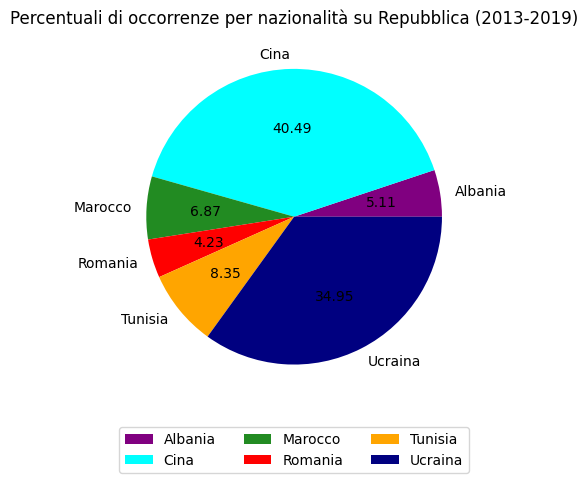

In [75]:
counts = df_frequenze["Frequenza assoluta"]
categories = df_frequenze["Nazionalità"]
colori = ["purple", "cyan", "forestgreen", "red", "orange", "navy"]

fig, ax = plt.subplots()
ax.pie(counts, labels=categories, colors=colori, autopct="%.2f")
ax.set_title("Percentuali di occorrenze per nazionalità su Repubblica (2013-2019)")
ax.legend(bbox_to_anchor=(0.5, -0.05), loc="upper center", ncol=3)

plt.show()

Vediamo come le comunità straniere **maggiormente rappresentate** in *La Repubblica* siano quella **cinese** (in azzurro) e quella **ucraina** (in blu), in percentuali nettamente superiori rispetto alle altre. 

Tale visibilità mediatica, però, risulta in contraddizione con quanto osservato in relazione alla presenza effettiva delle comunità target; per questo motivo mettiamo a confronto i dati fin qui analizzati con le dovute attenzioni. 

# UN CONFRONTO DEI DATI

Come anticipato, procediamo con un confronto tra i dati statistici emersi dall'analisi del dataset repubblica.csv e quelli rilevati nella nostra precedente indagine, nello stesso arco temporale.

## 1. Comparazione "mediatica"

Per ponderare correttamente l'impatto mediatico di ciascuna comunità, abbiamo deciso di non focalizzarci sul conteggio delle singole occorrenze, ottenuto in precedenza, ma sul conteggio degli articoli stessi. Eventuali ripetizioni all'interno degli articoli, infatti, potrebbero fornire risultati inesatti.

Per ogni singola nazionalità, dunque, contiamo quanti sono gli **articoli** che la citano in modo rilevante per il nostro studio: questo ci consentirà di operare una comparazione tra la rappresentazione di ciascuna comunità in Repubblica e l'effettiva presenza sul territorio della stessa.

Prima di fare ciò, filtriamo gli articoli che ci interessano, ovvero quelli che effettivamente citano le sei nazionalità target.

### ARTICOLI DI NOSTRO INTERESSE

Osservando il DataFrame `repubblica`, infatti, notiamo che la maggior parte degli articoli non cita le comunità da noi scelte (restituisce una riga di 0 in prossimità delle colonne count_*nazionalità*): possiamo, quindi, procedere ad escluderli in modo da visualizzare solo gli articoli di nostro interesse.

Creiamo quindi un dataframe `df_filtrato` che mostri quanti articoli menzionano i valori appartenenti al nostro `diz_nazionalità`:

In [76]:
# Creiamo una list comprehension
colonne_count = [f"count_{nazionalità.lower()}" for nazionalità in diz_nazionalità.keys()]
# essa genera una lista dei nomi delle colonne di conteggio create in precedenza > ["count_albania", "count_cina", "count_marocco", ...]. 

# Sommiamo i valori delle colonne di conteggio riga per riga
# Se la somma è > 0, l'articolo parla di almeno una comunità
articoli_selezionati = repubblica[colonne_count].sum(axis=1) > 0 
# axis=1 prende le righe (di default python prenderebbe le colonne > axis=0): i valori vengono sommati in orizzontale
# il "> 0" serve a filtrare gli articoli che parlano di almeno una comunità e funziona come un booleano:
# se la somma è maggiore di 0 restituisce True, quindi viene mantenuta la riga; viceversa, False, perciò la riga viene eliminata

# Applichiamo il filtro
df_filtrato = repubblica[articoli_selezionati].copy() # copy() crea un df a parte

print(f"Totale articoli che parlano delle nostre comunità nei contesti che ci interessano: {len(df_filtrato)}")
df_filtrato

Totale articoli che parlano delle nostre comunità nei contesti che ci interessano: 3892


,headline,full_text,url,count_albania,count_cina,count_marocco,count_romania,count_tunisia,count_ucraina
6,"Cina, ritrovato un dinosauro di specie sconosc...",HANNO fatto esplodere un'area rocciosa per cos...,http://www.repubblica.it/scienze/2016/11/11/ne...,0,1,0,0,0,0
8,"Renzi a Mosca da Putin: ""Insieme contro il ter...",MOSCA - Un importante accordo sulla strategia ...,http://www.repubblica.it/esteri/2015/03/05/new...,0,0,0,0,0,4
12,"Migranti, strage in mare. I tre superstiti: ""E...",Una strage. A bordo di quel gommone naufragato...,http://www.repubblica.it/cronaca/2019/01/19/ne...,0,0,1,0,0,0
18,"Ucraina, presidente chiede riunione straordina...","KIEV - Il Parlamento ucraino, su richiesta del...",http://www.repubblica.it/esteri/2014/01/23/new...,0,0,0,0,0,6
22,Cina: approvata legge che autorizza secondo fi...,PECHINO - Svolta storica in Cina. L'Assemblea ...,http://www.repubblica.it/esteri/2015/12/27/new...,0,4,0,0,0,0
...,...,...,...,...,...,...,...,...,...
63588,"Nuovo iPhone, iPad e poi in Tribunale. Che set...",TUTTO nel giro di qualche decina di ore: un nu...,https://www.repubblica.it/tecnologia/prodotti/...,0,1,0,0,0,0
63598,Celle 'piene' in Vaticano: in due nelle prigio...,CITTÀ DEL VATICANO – Due arresti ravvicinati: ...,http://www.repubblica.it/esteri/2014/12/26/new...,0,0,0,0,0,1
63632,"Archimedes, l'infiltrato della Cia nei compute...",Datemi una leva e un punto di appoggio e vi so...,http://www.repubblica.it/esteri/2017/05/05/new...,0,1,0,0,0,0
63650,"Cina, viaggio nell'universo Huawei",SHENZHEN - Dimenticate la Cina dei prodotti di...,https://www.repubblica.it/tecnologia/2016/11/2...,0,4,0,0,0,0


Come possiamo notare dalla visualizzazione di `df_filtrato`, ora ogni riga del dataframe contiene almeno un numero > 0 in count_*nazionalità*: questo ci garantisce che nell'articolo ne sia citata almeno una. Sono stati scartati tutti gli articoli per noi irrilevanti.

A questo punto tokenizziamo tutti i 3892 articoli selezionati e salviamo il testo diviso in token direttamente dentro una nuova colonna di un nuovo DataFrame `df_tokenizzato` (copia di `df_filtrato`, ma necessario per non apportare tale modifica direttamente sul `df_filtrato` di partenza), così da averlo pronto per le analisi future.

In [77]:
# Creiamo una lista vuota per contenere tutti i testi tokenizzati
nuova_repubblica_tokenizzata = []
# una volta riempita, si configurerà come una lista contenente 3.892 sottoliste, ognuna delle quali racchiude i token di ogni articolo

# Creiamo un ciclo for che prenda ogni articolo ("testo") di df_filtrato
for testo in df_filtrato["full_text"]:
    # Usiamo la funzione tokenizza su ogni articolo, la quale crea una lista di token
    token_articolo = tokenizza(testo)

    # Aggiungiamo la lista di token alla nostra lista principale
    nuova_repubblica_tokenizzata.append(token_articolo)

# Ora "nuova_repubblica_tokenizzata" è una lista di liste
# Dopo aver aggiunto alla lista principale ogni sottolista, possiamo aggiungerla come colonna al dataframe
df_tokenizzato = df_filtrato.copy()
df_tokenizzato["testo_tokenizzato"] = nuova_repubblica_tokenizzata

df_tokenizzato

,headline,full_text,url,count_albania,count_cina,count_marocco,count_romania,count_tunisia,count_ucraina,testo_tokenizzato
6,"Cina, ritrovato un dinosauro di specie sconosc...",HANNO fatto esplodere un'area rocciosa per cos...,http://www.repubblica.it/scienze/2016/11/11/ne...,0,1,0,0,0,0,"[hanno, fatto, esplodere, un, area, rocciosa, ..."
8,"Renzi a Mosca da Putin: ""Insieme contro il ter...",MOSCA - Un importante accordo sulla strategia ...,http://www.repubblica.it/esteri/2015/03/05/new...,0,0,0,0,0,4,"[mosca, un, importante, accordo, sulla, strate..."
12,"Migranti, strage in mare. I tre superstiti: ""E...",Una strage. A bordo di quel gommone naufragato...,http://www.repubblica.it/cronaca/2019/01/19/ne...,0,0,1,0,0,0,"[una, strage, a, bordo, di, quel, gommone, nau..."
18,"Ucraina, presidente chiede riunione straordina...","KIEV - Il Parlamento ucraino, su richiesta del...",http://www.repubblica.it/esteri/2014/01/23/new...,0,0,0,0,0,6,"[kiev, il, parlamento, ucraino, su, richiesta,..."
22,Cina: approvata legge che autorizza secondo fi...,PECHINO - Svolta storica in Cina. L'Assemblea ...,http://www.repubblica.it/esteri/2015/12/27/new...,0,4,0,0,0,0,"[pechino, svolta, storica, in, cina, l, assemb..."
...,...,...,...,...,...,...,...,...,...,...
63588,"Nuovo iPhone, iPad e poi in Tribunale. Che set...",TUTTO nel giro di qualche decina di ore: un nu...,https://www.repubblica.it/tecnologia/prodotti/...,0,1,0,0,0,0,"[tutto, nel, giro, di, qualche, decina, di, or..."
63598,Celle 'piene' in Vaticano: in due nelle prigio...,CITTÀ DEL VATICANO – Due arresti ravvicinati: ...,http://www.repubblica.it/esteri/2014/12/26/new...,0,0,0,0,0,1,"[città, del, vaticano, due, arresti, ravvicina..."
63632,"Archimedes, l'infiltrato della Cia nei compute...",Datemi una leva e un punto di appoggio e vi so...,http://www.repubblica.it/esteri/2017/05/05/new...,0,1,0,0,0,0,"[datemi, una, leva, e, un, punto, di, appoggio..."
63650,"Cina, viaggio nell'universo Huawei",SHENZHEN - Dimenticate la Cina dei prodotti di...,https://www.repubblica.it/tecnologia/2016/11/2...,0,4,0,0,0,0,"[shenzhen, dimenticate, la, cina, dei, prodott..."


Ora che abbiamo filtrato gli articoli di nostro interesse, possiamo procedere a contare il **numero di articoli** in cui ciascuna comunità viene citata:

In [ ]:
# Creiamo un dizionario vuoto in cui la chiave sarà la nazionalità (es. "Albania") e il valore sarà il numero totale di articoli che la menzionano.
conteggio_articoli = {}

# Creiamo un ciclo for che scorre le chiavi del dizionario "diz_nazionalità" (es. "Albania") 
# e ricostruisce il nome della colonna corrispondente presente nel DataFrame (es. "count_albania")
for nazionalità in diz_nazionalità.keys():
    # Creiamo la variabile "nome_colonna", che useremo in seguito per il conteggio
    nome_colonna = f"count_{nazionalità.lower()}"

    # Verifichiamo, riga per riga (articolo per articolo), se il valore della colonna è maggiore di zero
    numero_articoli = int((df_tokenizzato[nome_colonna] > 0).sum()) # int restituisce un intero pulito
    # come nel codice precedente, se c'è un valore maggiore di 0 allora abbiamo un booleano True, che viene trasformato in 1
    # in questo modo non sommiamo i numeri ma soltanto se vi è o meno un articolo, ottenendone il totale

    # Associamo la somma degli articoli alla chiave nazionalità
    conteggio_articoli[nazionalità] = numero_articoli

print(f"Totale articoli che parlano di Albania: {conteggio_articoli['Albania']}")
print(f"Totale articoli che parlano di Cina: {conteggio_articoli['Cina']}")
print(f"Totale articoli che parlano di Marocco: {conteggio_articoli['Marocco']}")
print(f"Totale articoli che parlano di Romania: {conteggio_articoli['Romania']}")
print(f"Totale articoli che parlano di Tunisia: {conteggio_articoli['Tunisia']}")
print(f"Totale articoli che parlano di Ucraina: {conteggio_articoli['Ucraina']}")

conteggio_articoli

Totale articoli che parlano di Albania: 283
Totale articoli che parlano di Cina: 1925
Totale articoli che parlano di Marocco: 396
Totale articoli che parlano di Romania: 283
Totale articoli che parlano di Tunisia: 356
Totale articoli che parlano di Ucraina: 981


{'Albania': 283,
 'Cina': 1925,
 'Marocco': 396,
 'Romania': 283,
 'Tunisia': 356,
 'Ucraina': 981}

### Visualizziamo i risultati ottenuti 

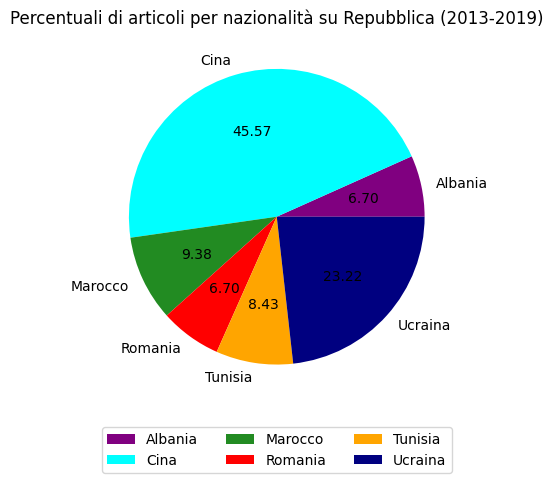

In [79]:
comunità = conteggio_articoli.keys()
articoli_rilevanti = conteggio_articoli.values()
colori = ["purple", "cyan", "forestgreen", "red", "orange", "navy"]

fig, ax = plt.subplots()
ax.pie(articoli_rilevanti, labels=comunità, colors=colori, autopct="%.2f")
ax.set_title("Percentuali di articoli per nazionalità su Repubblica (2013-2019)")
ax.legend(bbox_to_anchor=(0.5, -0.05), loc="upper center", ncol=3)

plt.show()

Come possiamo vedere, le percentuali relative agli articoli presentano alcune variazioni rispetto a quelle relative alle occorrenze, riportate nel grafico `Percentuali di occorrenze per nazionalità su Repubblica (2013-2019)`. Spicca in particolare il caso dell'Ucraina, in cui a una percentuale di occorrenze pari a circa il 35% fa da contrappunto una piuttosto inferiore, pari circa al 23% di articoli. 

In ogni caso, le distribuzioni risultano comunque piuttosto coerenti tra i due grafici: l'attenzione mediatica si riconferma principalmente rivolta alla comunità cinese e a quella ucraina.

Riportiamo nuovamente il grafico creato in precedenza dal dataframe `media_nazionalità` per permettere un confronto visivo con il precedente:

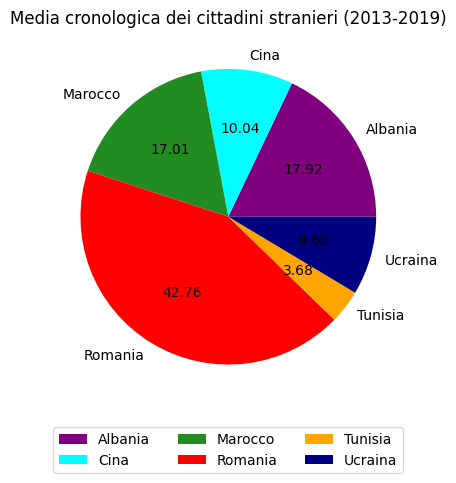

In [80]:
dati = media_nazionalità.reset_index()

popolazione = dati["Totale"]
comunità = dati["Stato di cittadinanza"]
colori = ["purple", "cyan", "forestgreen", "red", "orange", "navy"]

fig, ax = plt.subplots()
ax.pie(popolazione, labels=comunità, colors=colori, autopct="%.2f")
ax.set_title("Media cronologica dei cittadini stranieri (2013-2019)")
ax.legend(bbox_to_anchor=(0.5, -0.05), loc="upper center", ncol=3)

plt.show()

### Cosa possiamo trarre da questo confronto?
Dalla comparazione dei due grafici emerge in modo immediato una netta discrepanza tra la consistenza demografica effettiva delle comunità straniere e la loro rappresentazione mediatica sulle pagine di Repubblica. Di seguito viene proposta l'analisi per ciascuna nazionalità target:
- Albania (marcata sottorappresentazione): pur registrando una presenza significativa sul territorio pari circa al 18%, la comunità albanese viene intercettata dal discorso mediatico in meno del 7% dei casi, configurando un evidente deficit di rappresentazione.
- Cina (massima sovrarappresentazione): costituisce il caso di discrepanza più macroscopico dell'intero dataset. Alla percentuale demografica del 10% fa da contrappunto una presenza in oltre il 45% negli articoli di Repubblica.
- Marocco (sottorappresentazione): seppur sia la terza comunità per presenza reale (17%), la quota di articoli è meno del 10%.
- Romania (massima sottorappresentazione): rappresenta il fenomeno opposto e speculare rispetto al caso cinese. La comunità rumena è di gran lunga la più numerosa sul territorio nazionale, costituendo circa il 43% del totale. Ciononostante, essa risulta quasi invisibile sulla stampa, con meno del 7% di articoli dedicati.
- Tunisia (moderata sovrarappresentazione): si riscontra una tendenza alla sovrarappresentazione della comunità tunisina, presente nell'8% degli articoli ma in poco meno del 4% del territorio. 
- Ucraina (forte sovrarappresentazione): analogamente al caso cinese, si registra un marcato sbilanciamento verso l'alto. Pur rappresentando meno del 9% degli stranieri residenti considerati, alla comunità ucraina è dedicato quasi un quarto del totale degli articoli (23%).

In sintesi, i dati dimostrano la totale assenza di correlazione statistica tra l'effettivo numero dei cittadini residenti in Italia e lo spazio loro dedicato sui media. Le discrepanze osservate sono profonde e variano sensibilmente a seconda della nazionalità presa in esame.

## 2. Comparazione "geografica"
Così come abbiamo paragonato la presenza delle singole comunità all'interno del dataset di Repubblica con la loro presenza effettiva sul territorio italiano, facciamo lo stesso paragone ma considerando le ripartizioni geografiche. 
In particolare, mettiamo a confronto la **distribuzione territoriale effettiva dei cittadini stranieri**, ricavata dai dati ISTAT relativi alla cittadinanza (secondo grafico), con la **frequenza di co-occorrenza** tra le nazionalità considerate e alcuni riferimenti geografici presenti negli articoli del corpus.

Il nostro scopo, anche in questo caso, è di cercare eventuali correlazioni tra i due dataset e capire se i giornali tendono ad **associare certe nazionalità a certe zone d'Italia**.

Per questa fase dell’analisi definiamo un dizionario `località_target`, nel quale alcune città, regioni e località italiane vengono associate alle quattro principali ripartizioni geografiche considerate (Nord, Centro, Sud, Isole). 

Successivamente, attraverso un triplo ciclo for, analizziamo ciascun articolo del corpus tokenizzato. Per ogni articolo, il codice verifica anzitutto la presenza di una determinata nazionalità tramite la funzione `conta_frequenza()`. Se l’articolo contiene almeno una menzione valida della nazionalità considerata, il programma procede a controllare anche la presenza delle località associate alle diverse aree geografiche. Le occorrenze delle località rilevate vengono quindi sommate all’interno di una struttura dati nested (`incrocio_nazionalità_luogo`), organizzata per nazionalità e zona geografica.

Questo procedimento ci consente di ottenere un dataframe (`df_risultati`) che illustra, seppur a livello generale e non metodologicamente accurato, la frequenza con cui ciascuna comunità viene citata in correlazione con le quattro principali ripartizioni geografiche considerate.

In [94]:
# CREIAMO UN DIZIONARIO LOCALITÀ
località_target = {
    "Centro": [
        # Regioni
        "lazio", "umbria", "marche", "toscana",
        # Capoluoghi e città principali
        "roma", "firenze", "perugia", "ancona", "livorno", "pisa", "prato", "siena"
    ],
    "Isole": [
            # Regioni
            "sicilia", "sardegna",
            # Capoluoghi e città principali
            "palermo", "catania", "cagliari", "messina", "lampedusa", "pozzallo", "ragusa", "sassari"
    ],
    "Nord": [
            # Regioni
            "lombardia", "piemonte", "veneto", "emilia-romagna", "liguria", "friuli", "trentino", "valle d'aosta",
            # Capoluoghi e città principali
            "milano", "torino", "bologna", "venezia", "genova", "verona", "padova", "brescia", 
    ],
    "Sud": [
        # Regioni
        "campania", "puglia", "calabria", "basilicata", "abruzzo", "molise", 
        # Capoluoghi e città principali
        "napoli", "bari", "reggio calabria", "foggia", "salerno", "brindisi", "taranto", "caserta"
    ],
}

# CREIAMO UN CONTENITORE PER I RISULTATI INCROCIATI
# Struttura del nostro dizionario "nested": { "Cinesi": {"Nord": 0, "Centro": 0...}, "Rumeni": {"Nord": 0...} } > inizializziamo a 0
incrocio_nazionalità_luogo = {nazionalità: {zona: 0 for zona in località_target} for nazionalità in diz_nazionalità}

# TRIPLO CICLO FOR
# 1. Prendiamo ogni articolo uno per uno
for testo in df_tokenizzato["testo_tokenizzato"]:
    
    # 2. Prendiamo ogni nazionalità una per una
    for nazionalità, varianti_nazionalità in diz_nazionalità.items():
        # L'articolo parla di questa nazionalità?
        # Qui usiamo conta_frequenza (con disambiguazione Stato/persona e filtro parole_fuorvianti), perché questi filtri sono pensati proprio per le nazionalità
        if conta_frequenza(testo, varianti_nazionalità) > 0: 
        # se la risposta è False (0), ignora tutto il resto e passa alla nazione successiva
        # se c'è effettivamente la nazionalità iterata (True), passiamo al livello successivo: controlliamo se tale nazionalità è associata a un qualche luogo

            # 3. Iteriamo ogni luogo con un terzo ciclo for
            for zona, varianti_luogo in località_target.items(): 
                # Qui usiamo conta_frequenza_semplice, senza i filtri pensati per le nazionalità (disambiguazione Stato/persona e parole_fuorvianti non sono pertinenti per i nomi di luogo)
                conteggio_luogo = conta_frequenza_semplice(testo, varianti_luogo)
                # Aggiungiamo il numero di volte che la località è citata in relazione alla specifica nazionalità
                incrocio_nazionalità_luogo[nazionalità][zona] += conteggio_luogo 
                # es. incrocio_nazionalità_luogo["Cina"]["centro"] = 15 > i cinesi al centro vengono citati 15 volte


# Creiamo una tabella per una più agevole visualizzazione
df_risultati = pd.DataFrame(incrocio_nazionalità_luogo)
df_risultati

,Albania,Cina,Marocco,Romania,Tunisia,Ucraina
Centro,513,1130,443,389,354,485
Isole,119,181,140,100,297,130
Nord,417,858,497,234,343,276
Sud,308,301,149,217,113,155


### Visualizziamo i risultati ottenuti


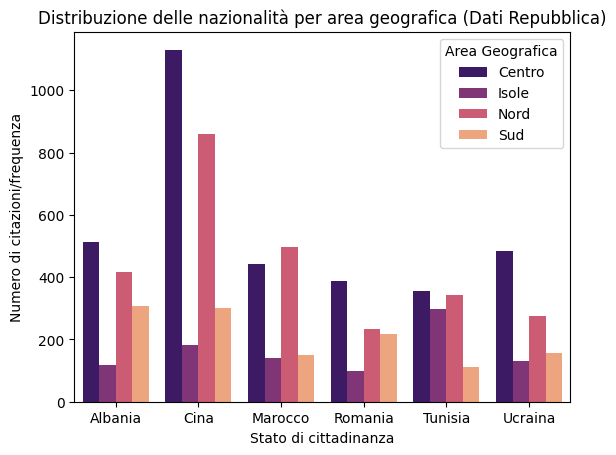

In [95]:
df_risultati.index.name = "Zona"
barplot_aree_repubblica = df_risultati.reset_index()

# Trasformiamo il DataFrame in formato "long" con il metodo .melt()
df_long = barplot_aree_repubblica.melt(id_vars="Zona", var_name="nazionalità", value_name="Frequenza") 
# id_vars serve a mantenere "zona" come riferimento
# var_name prende i nomi delle vecchie colonne delle nazioni (Albania, Cina, ecc.) e li fa diventare righe dentro un'unica nuova colonna chiamata "nazionalità".
# value_name prende i numeri dei conteggi che erano dentro la tabella e li mette tutti in una nuova colonna chiamata "Frequenza"

sns.barplot(data=df_long, x="nazionalità", y="Frequenza", hue="Zona", palette="magma")

plt.title("Distribuzione delle nazionalità per area geografica (Dati Repubblica)")
plt.xlabel("Stato di cittadinanza")
plt.ylabel("Numero di citazioni/frequenza")
plt.legend(title="Area Geografica")

plt.show()

Tramite questo grafico possiamo confrontare in maniera visiva ed immediata i dati ottenuti con il dataframe `media_aree`, che avevamo precedentemente rappresentato:

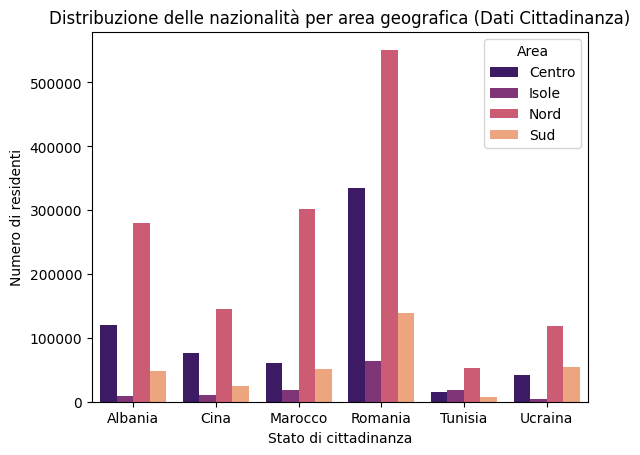

In [83]:
sns.barplot(data=media_aree, x="Stato di cittadinanza", y="Totale", hue="Denominazione", palette = "magma")

plt.title("Distribuzione delle nazionalità per area geografica (Dati Cittadinanza)")
plt.xlabel("Stato di cittadinanza")
plt.ylabel("Numero di residenti")
plt.legend(title="Area")

plt.show()

### Cosa possiamo trarre da questi dati?

Dall'incrocio dei dati emergono, ancora una volta, alcune interessanti discrepanze tra la **distribuzione** demografica reale sul territorio e la **narrazione** giornalistica:

1. Il grafico relativo ai dati di cittadinanza reale evidenzia come la presenza dei cittadini stranieri residenti sia fortemente polarizzata nelle regioni del **Nord Italia**. Al contrario, l'analisi delle **co-occorrenze testuali** (il primo grafico) mostra una netta tendenza della stampa ad associare le comunità straniere a contesti ed eventi ambientati nel **Centro Italia**. Si rileva, dunque, uno sbilanciamento della narrazione mediatica verso l'area geografica centrale rispetto alla reale distribuzione sul territorio.

2. L'evidenza più significativa di questa distorsione si riscontra nei dati relativi alla cittadinanza cinese. Sul piano demografico la comunità cinese è meno consistente rispetto ad altre nazionalità (come quella rumena o marocchina), mantenendo una prevalenza quantitativa nel Nord del Paese. Sul piano della rappresentazione (dati Repubblica), come già discusso, l'attenzione mediatica dedicata a questa comunità è tra le più elevate in assoluto del dataset, con un notevole picco di citazioni che la collegano prevalentemente alle località del **Centro**. Questa evidente asimmetria tra il dato reale (prevalenza al Nord) e il dato mediatico (sovrarappresentazione al Centro) potrebbe essere frutto di specifici stereotipi territoriali, che tendono ad associare la presenza della comunità cinese a aree come Prato e Firenze.

3. Infine, come già reso evidente dai grafici riportati sopra, relativi alla presenza generale delle sei comunità straniere in Italia (`Media cronologica dei cittadini stranieri (2013-2019)`), viene confermata la **sottorappresentazione** della Romania rispetto alla reale presenza sul territorio.


## 3. Comparazione "cronologica"
Un'ulteriore analisi che possiamo condurre è quella relativa all'evoluzione temporale: nella prima parte del lavoro abbiamo osservato variazioni demografiche nell'arco cronologico selezionato, illustrate tramite grafici. Questa variazione è rappresentata all'interno del dataset di Repubblica?

In questa sezione analizziamo quindi la **distribuzione temporale** delle menzioni delle sei comunità straniere all'interno del corpus di articoli. Per farlo, come si può osservare dal seguente codice, estraiamo l'anno dall'url di ciascun articolo, creando una nuova colonna **"anno"** all'interno del `df_tokenizzato`, al fine di visualizzare la data di pubblicazione degli articoli.

In [97]:
# Estrai l'anno con la regex 
match = r"/(201[3-9])/"
df_tokenizzato["anno"] = df_tokenizzato["url"].str.extract(match)
# str.extract() restituisce l'elemento tra parentesi, in questo caso il match, che trova nella stringa

df_tokenizzato

,headline,full_text,url,count_albania,count_cina,count_marocco,count_romania,count_tunisia,count_ucraina,testo_tokenizzato,anno
6,"Cina, ritrovato un dinosauro di specie sconosc...",HANNO fatto esplodere un'area rocciosa per cos...,http://www.repubblica.it/scienze/2016/11/11/ne...,0,1,0,0,0,0,"[hanno, fatto, esplodere, un, area, rocciosa, ...",2016
8,"Renzi a Mosca da Putin: ""Insieme contro il ter...",MOSCA - Un importante accordo sulla strategia ...,http://www.repubblica.it/esteri/2015/03/05/new...,0,0,0,0,0,4,"[mosca, un, importante, accordo, sulla, strate...",2015
12,"Migranti, strage in mare. I tre superstiti: ""E...",Una strage. A bordo di quel gommone naufragato...,http://www.repubblica.it/cronaca/2019/01/19/ne...,0,0,1,0,0,0,"[una, strage, a, bordo, di, quel, gommone, nau...",2019
18,"Ucraina, presidente chiede riunione straordina...","KIEV - Il Parlamento ucraino, su richiesta del...",http://www.repubblica.it/esteri/2014/01/23/new...,0,0,0,0,0,6,"[kiev, il, parlamento, ucraino, su, richiesta,...",2014
22,Cina: approvata legge che autorizza secondo fi...,PECHINO - Svolta storica in Cina. L'Assemblea ...,http://www.repubblica.it/esteri/2015/12/27/new...,0,4,0,0,0,0,"[pechino, svolta, storica, in, cina, l, assemb...",2015
...,...,...,...,...,...,...,...,...,...,...,...
63588,"Nuovo iPhone, iPad e poi in Tribunale. Che set...",TUTTO nel giro di qualche decina di ore: un nu...,https://www.repubblica.it/tecnologia/prodotti/...,0,1,0,0,0,0,"[tutto, nel, giro, di, qualche, decina, di, or...",2016
63598,Celle 'piene' in Vaticano: in due nelle prigio...,CITTÀ DEL VATICANO – Due arresti ravvicinati: ...,http://www.repubblica.it/esteri/2014/12/26/new...,0,0,0,0,0,1,"[città, del, vaticano, due, arresti, ravvicina...",2014
63632,"Archimedes, l'infiltrato della Cia nei compute...",Datemi una leva e un punto di appoggio e vi so...,http://www.repubblica.it/esteri/2017/05/05/new...,0,1,0,0,0,0,"[datemi, una, leva, e, un, punto, di, appoggio...",2017
63650,"Cina, viaggio nell'universo Huawei",SHENZHEN - Dimenticate la Cina dei prodotti di...,https://www.repubblica.it/tecnologia/2016/11/2...,0,4,0,0,0,0,"[shenzhen, dimenticate, la, cina, dei, prodott...",2016


Sebbene gli articoli di Repubblica, come più volte ribadito, coprano l'arco temporale che va dal 2013 al 2019, per evitare refusi dovuti alla presenza di altre date negli url, abbiamo comunque specificato tali anni nella regex per essere certe di filtrare solo gli articoli di nostro interesse. 

Un ulteriore aspetto da chiarire riguarda il fatto che circa sessanta articoli sono privi di url: per questi, non è stato possibile rintracciare il corrispettivo anno di pubblicazione e, inevitabilmente, alcune occorrenze sono andate perse.

Adesso possiamo raggruppare i dati in base all'anno estratto ed ottenere un dataframe sulle frequenze annue: `df_articoli_annui`.

In [85]:
# Creiamo una list comprehension
colonne_paesi = [col for col in df_tokenizzato.columns if col.startswith("count_")]
# la lista "colonne_paesi" conterrà tutti i nomi delle colonne che iniziano con la parola "count_" > ["count_albania", "count_cina", "count_marocco", ...]

df_annuo = df_tokenizzato.copy() # creiamo una copia per non alterare il df originale

# Iteriamo su ogni colonna (ovvero su ogni membro della lista "colonne_paesi")
# Questo ciclo analizza le colonne in modo indipendente, perciò funziona anche se l'articolo parla di due nazionalità
for col in colonne_paesi:
    df_annuo[col] = df_annuo[col] > 0
    # df_annuo[col] > 0 genera dei booleani (True/False).
    # ogni riga ora contiene 1 (parla della nazione) o 0 (non ne parla)

# Raggruppiamo per anno
df_articoli_annui = df_annuo.groupby("anno")[colonne_paesi].sum()
# la somma restituisce il totale di articoli che parlano di ogni nazionalità
df_articoli_annui

,count_albania,count_cina,count_marocco,count_romania,count_tunisia,count_ucraina
anno,,,,,,
2013,12,99,14,12,8,39
2014,37,282,51,56,42,411
2015,56,302,105,54,104,196
2016,76,397,71,52,80,117
2017,57,414,80,49,49,109
2018,34,337,53,46,66,89
2019,5,62,17,8,4,7


### Visualizziamo i risultati

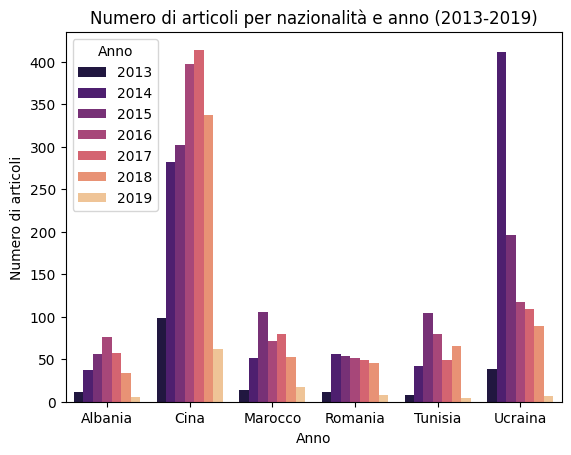

In [98]:
df_grafico = df_articoli_annui.copy()
df_grafico = df_articoli_annui.reset_index()

# Trasformiamo il dataframe in formato "long" 
df_long = df_grafico.melt(id_vars="anno", var_name="Paese", value_name="Articoli")
df_long["Paese"] = df_long["Paese"].str.replace("count_", "").str.capitalize()

sns.barplot(data=df_long, x="Paese", y="Articoli", hue="anno", palette="magma")

plt.title("Numero di articoli per nazionalità e anno (2013-2019)")
plt.xlabel("Anno")
plt.ylabel("Numero di articoli")
plt.legend(title="Anno")

plt.show()

Dal grafico si può osservare un'anomalia nei dati relativi al 2013 e al 2019, molto meno consistenti rispetto agli altri. Infatti, sebbene nel dataset fornito ci siano articoli databili a tali anni, essi sono molto meno numerosi. Per tale ragione, nella successiva analisi comparativa, escluderemo dalla riflessione conclusioni relative ai due anni in questione.

Riproponiamo il grafico che mostrava la variazione cronologica della distribuzione dei cittadini in Italia che abbiamo creato precedentemente:

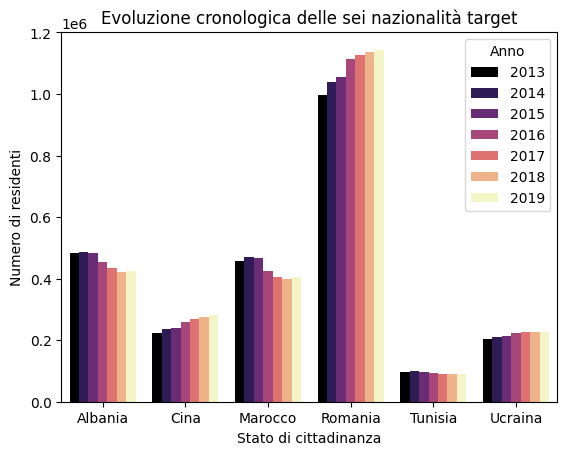

In [87]:
df_plot = df_istat.reset_index()

sns.barplot(data=df_plot, x="Stato di cittadinanza", y="Totale", hue="Anno", palette="magma")

plt.title("Evoluzione cronologica delle sei nazionalità target")
plt.xlabel("Stato di cittadinanza")
plt.ylabel("Numero di residenti")
plt.legend(title="Anno")

plt.show()

### Cosa possiamo trarre da questi dati?
Se confrontiamo l'andamento dei due grafici, risulta immediatamente evidente un dato fondamentale: il numero di volte in cui una comunità straniera viene citata su Repubblica non rispecchia la reale evoluzione cronologica. 

1. Questa discrepanza è massimamente evidente per il caso dell'**Ucraina**: nel 2014 le citazioni relative a tale comunità subiscono un incremento notevolissimo, sebbene la crescita demografica risulti quasi trascurabile. Ciò, come si evince dal secondo grafico, non dipende da un'effettiva ondata migratoria nel paese, ma ha una spiegazione geopolitica: l'invasione della Crimea da parte della Russia, avvenuta proprio nel 2014. Finito l'allarme, l'attenzione crolla, in modo del tutto indipendente dalla presenza effettiva della comunità sul territorio.

2. Oltre a questo dato, emerge, in modo altrettanto chiaro, il rapporto inversamente proporzionale tra la quantità di residenti e la sovrarappresentazione della **Cina** da un lato, la sottorappresentazione della **Romania** dall'altro.

3. Infine, notiamo che per ogni comunità si riscontrano dei picchi di citazioni in determinati anni, senza che questo rifletta un effettivo aumento demografico, come evidenziato per il caso eclatante dell'Ucraina.

# COME VENGONO CONNOTATI GLI IMMIGRATI IN REPUBBLICA?

Il terzo ed ultimo obiettivo del presente lavoro, ovvero intercettare l'esistenza di associazioni terminologiche tra comunità straniere e parole con differenti connotazioni, si sviluppa come un'analisi qualitativa. Tale analisi si propone di verificare se alcune comunità vengono rappresentate in modo più o meno positivo nei media. 

Dopo aver definito il dizionario `framing`, contenente alcuni sostantivi e aggettivi riconducibili a tre principali accezioni (positiva, negativa e neutra), verifichiamo l'eventuale co-occorrenza dei termini contenuti in tale dizionario con i termini contenuti in `diz_nazionalità`. Il codice crea, per ogni articolo, un set di indici di contesto, ovvero gli indici delle parole che si trovano intorno a `varianti` di `diz_nazionalità`, entro la finestra predefinita. In questo modo, se all'interno della stessa finestra che include la variante in questione compare la stessa variante o una di quelle ammesse dalla chiave di `diz_nazionalità` (es. "*Ci sono marocchini rifugiati e marocchini che fuggono*"), in correlazione con una parola di framing (nell'esempio "*rifugiati*"), quest'ultima non viene contata due volte ma solo una.  Infatti, poiché un set non ammette duplicati, un indice che ricade nella finestra di più occorrenze viene inserito una sola volta. Solo in un secondo momento scorriamo questo insieme di indici e contiamo le parole di framing, garantendo che ciascuna parola di contesto contribuisca una sola volta al conteggio finale, indipendentemente da quante occorrenze della stessa nazionalità la includono nella propria finestra.

In [ ]:
# Definiamo il dizionario 
framing = {
"parole_negative" : ["clandestino", "clandestini", "clandestina", "clandestine", "irregolare", "irregolari", "abusivo", "abusivi", "abusiva", "abusive", "espulso", "espulsi", "espulsa", "espulse"],
"parole_neutre" : ["immigrato", "immigrati", "immigrata", "immigrate", "migrante", "migranti", "straniero", "stranieri", "straniera", "straniere", "profugo", "profughi", "profuga", "profughe"],
"parole_positive" : ["rifugiato", "rifugiati", "rifugiata", "rifugiate", "evacuato", "evacuati", "evacuata", "evacuate", "asilo", "accolto", "accolti", "accolta", "accolte", "accoglienza", "integrazione"]
}

# Inizializziamo il contenitore per i risultati
analisi_accezione = {nazionalità: {"Positive": 0, "Neutre": 0, "Negative": 0} for nazionalità in diz_nazionalità}

# Finestra di contesto: controlliamo le dieci parole precedenti e le dieci successive
finestra = 10

# Ciclo for sul testo tokenizzato
for tokens in df_tokenizzato["testo_tokenizzato"]:
    
    # Per ogni articolo, raccogliamo per ciascuna nazionalità l'INSIEME (set) degli indici di contesto coinvolti, 
    # così le finestre sovrapposte non producono indici duplicati
    indici_contesto_per_nazionalità = {nazionalità: set() for nazionalità in diz_nazionalità}
    # dictionary comprehension: per ogni nazionalità in diz_nazionalità viene creata una coppia chiave (nazionalità) valore (set())
    
    # Individuiamo le occorrenze di ogni nazionalità e uniamo le loro finestre
    for i, parola in enumerate(tokens):
        for nazionalità, varianti in diz_nazionalità.items():
            if parola in varianti:
                inizio = max(0, i - finestra)
                # max(0, ...) evita di andare sottozero se la parola è all'inizio dell'articolo
                fine = min(len(tokens), i + finestra + 1)
                # min(len(...), ...) evita di superare la fine dell'articolo se la parola è verso il fondo
                # Aggiungiamo gli indici della finestra all'insieme (i duplicati vengono ignorati automaticamente)
                indici_contesto_per_nazionalità[nazionalità].update(range(inizio, fine))
                # .update() unisce gli indici senza duplicati: evita il doppio conteggio
                # quando le finestre di due occorrenze analoghe si sovrappongono
    
    # Per ogni nazionalità, contiamo il framing una sola volta per indice
    for nazionalità, indici in indici_contesto_per_nazionalità.items():
        for idx in indici:
            parola_contesto = tokens[idx]
            if parola_contesto in framing["parole_positive"]:
                analisi_accezione[nazionalità]["Positive"] += 1
            elif parola_contesto in framing["parole_neutre"]:
                analisi_accezione[nazionalità]["Neutre"] += 1
            elif parola_contesto in framing["parole_negative"]:
                analisi_accezione[nazionalità]["Negative"] += 1

# Trasformiamo i risultati in un DataFrame leggibile
df_accezioni = pd.DataFrame(analisi_accezione) 
df_accezioni

,Albania,Cina,Marocco,Romania,Tunisia,Ucraina
Positive,4,24,13,2,5,35
Neutre,34,47,41,14,44,33
Negative,6,7,15,1,14,3


### Visualizziamo i risultati ottenuti

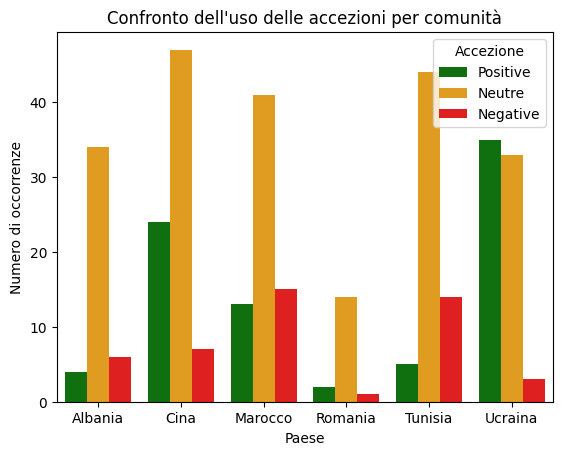

In [99]:
df_accezioni.index.name = "Accezione"
df_framing_per_nazionalità = df_accezioni.reset_index()

# Trasformiamo il DataFrame dal formato "largo" al formato "lungo" 
df_long = pd.melt(df_framing_per_nazionalità, id_vars=["Accezione"], var_name="Paese", value_name="Conteggio")

sns.barplot(data=df_long, x="Paese", y="Conteggio", hue="Accezione", palette= ("green","orange", "red"))

plt.title("Confronto dell'uso delle accezioni per comunità")
plt.xlabel("Paese")
plt.ylabel("Numero di occorrenze")
plt.legend(title="Accezione")

plt.show()

### Cosa possiamo trarre da questi dati?

Si osserva chiaramente che le parole più utilizzate in assoluto sono quelle non marcate per accezione (ovvero `"parole_neutre"`); in riferimento a ciascuna delle comunità esaminate, infatti, queste ultime registrano frequenze ampiamente superiori. Soffermiamoci ora, in modo comparativo, sulle occorrenze dei termini con accezione positiva o negativa:
- Albania: si registra un numero appena superiore di termini con accezione negativa rispetto a quella positiva;
- Cina: prevalgono in modo netto i termini con accezione positiva, che superano il doppio delle occorrenze negative;
- Marocco: si evidenzia una prevalenza di termini negativi rispetto a quelli positivi;
- Romania: le due polarità si equivalgono quasi perfettamente, registrando una sola occorrenza per l'accezione negativa e due per quella positiva;
- Tunisia: i termini con accezione negativa sono nettamente superiori rispetto a quelli positivi;
- Ucraina: sussiste una marcata prevalenza di termini con accezione positiva rispetto alla controparte negativa; inoltre è l'unico caso in cui i termini positivi sono superiori anche di quelli neutri.

Tali differenze, seppur contenute, sono legate a stereotipi generalizzati (e consolidati anche dai media stessi) o sono del tutto casuali? In questa sede non cercheremo di dare una risposta, ma, quantomeno, alla luce dei dati, porsi una tale domanda è più che lecito.

### Per completezza, operiamo un conteggio delle parole presenti in `framing` sul totale degli articoli

In [100]:
# Creiamo un dizionario con 3 chiavi e i cui valori sono inizializati a 0
conteggi_framing = {"parole_negative": 0, "parole_neutre": 0, "parole_positive": 0}

# Utilizziamo la funzione di conteggio semplice
for articolo in nuova_repubblica_tokenizzata:
    for categoria, varianti in framing.items():
        n = conta_frequenza_semplice(articolo, varianti)
        conteggi_framing[categoria] += n

print(f"I termini con connotazione negativa compaiono {conteggi_framing['parole_negative']} volte in totale")
print(f"I termini con connotazione neutra compaiono {conteggi_framing['parole_neutre']} volte in totale")
print(f"I termini con connotazione positiva compaiono {conteggi_framing['parole_positive']} volte in totale")

I termini con connotazione negativa compaiono 405 volte in totale
I termini con connotazione neutra compaiono 3044 volte in totale
I termini con connotazione positiva compaiono 1606 volte in totale


### Visualizziamo i risultati ottenuti

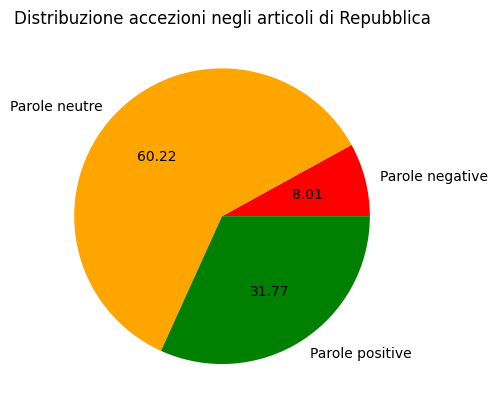

In [101]:
categorie = ["Parole negative", "Parole neutre", "Parole positive"]
valori = list(conteggi_framing.values())
colori = ["red", "orange", "green"]

fig, ax = plt.subplots()
ax.pie(valori, labels=categorie, colors=colori, autopct="%.2f")
plt.title("Distribuzione accezioni negli articoli di Repubblica")

plt.show()

Anche sul totale degli articoli la percentuale nettamente superiore è rappresentata dalle `"parole neutre"`; queste sono seguite dalle positive e, in ultimo posto, dalle negative.

# CONCLUSIONI
Ripercorriamo in questa sede i risultati ottenuti in relazione a ciascun obiettivo del lavoro. 

1. Il primo obiettivo del progetto era di natura statistico-distribuzionale: indagare la presenza e l'evoluzione demografica di ciascuna delle sei comunità "target", e analizzare eventuali discrepanze nella distribuzione territoriale di queste ultime. Ciò che ne è emerso è che, tra le comunità straniere considerate, quella maggiormente consistente nella penisola è la comunità rumena. Il picco registrato è di oltre un milione di abitanti, ovvero più del doppio rispetto ai numeri relativi alla comunità albanese e marocchina, seconde per numero di abitanti. Seguono la comunità cinese, ucraina e tunisina, demograficamente molto meno cospicue. Per quanto concerne la distribuzione nelle diverse aree geografiche (Nord, Centro, Sud e Isole), il Nord spicca come porzione di penisola più densamente popolata dalle sei cittadinanze selezionate. Anche al Centro i numeri risultano notevoli.

2. Il secondo obiettivo si proponeva di indagare se la narrazione giornalistica attorno a tali comunità fosse quantitativamente coerente rispetto all'effettiva presenza di queste ultime sul suolo italiano. Dopo aver sviluppato un'euristica funzionale a escludere occorrenze potenzialmente fuorvianti, abbiamo creato due codici principali: uno che restituisce il numero di occorrenze che citano direttamente le nostre comunità, e un altro che calcola il numero di articoli in cui tali comunità vengono menzionate almeno una volta. Per i tre confronti successivi ci siamo avvalse di entrambi. Vediamoli nel dettaglio:

- Comparazione "mediatica": nel primo dei tre confronti abbiamo preso in considerazione il numero di articoli filtrati, e lo abbiamo comparato ai numeri effettivi di ciascuna comunità, ottenuti tramite analisi statistica nella prima parte del lavoro. Ciò corrisponde specificamente al secondo obiettivo prefissato. Da tale analisi sono emerse alcune interessanti polarizzazioni, riguardanti principalmente la comunità rumena da un lato, e quella cinese e ucraina dall'altro. La prima si connota in termini di massima sottorappresentazione: a una predominante presenza sul territorio, infatti, fa da contrappunto una rappresentazione mediatica molto debole. Cina e Ucraina, invece, si caratterizzano per l'opposto: sebbene, come ribadito, non raggiungano vette demografiche particolarmente rilevanti, sono intercettate dalla maggior parte del discorso mediatico. Le altre tre comunità, albanese, marocchina e tunisina, si connotano le prime due per una moderata sottorappresentazione, la terza per una moderata sovrarappresentazione.

- Comparazione "geografica": per questo secondo confronto ci siamo invece avvalse del numero di occorrenze. In particolare, abbiamo cercato di verificare se la distribuzione geografica effettiva delle comunità straniere risultasse coerente con la frequenza di co-occorrenza tra le nazionalità considerate e le diverse ripartizioni geografiche menzionate negli articoli di Repubblica. Abbiamo rilevato che tali nazionalità risultano perlopiù associate alle zone del Centro Italia, sebbene, come emerso dall'analisi precedente, esse siano più ampiamente distribuite nel Nord. Il caso più eclatante riguarda la comunità cinese, per cui, forse a causa di alcuni stereotipi territoriali, l'associazione con città del Centro Italia risulta essere massima.

- Comparazione "cronologica": il terzo ed ultimo confronto si avvale, ancora una volta, del conteggio degli articoli. Nello specifico, abbiamo voluto esaminare eventuali correlazioni tra l'evoluzione demografica nel tempo e variazioni nel numero di articoli nello stesso arco cronologico. Da tale analisi non è risultata alcuna evidenza significativa che testimoniasse una coerenza tra oscillazioni demografiche e aumenti o diminuzioni di articoli relativi alle comunità straniere. Il caso più interessente riguarda il picco di articoli che citano la comunità ucraina nel 2014, giustificato, come spiegato, dall'esplosione del conflitto in Crimea.

3. Il terzo ed ultimo obiettivo si proponeva di indagare eventuali associazioni terminologiche all'interno del dataset repubblica.csv tra parole diversificate per accezione e citazioni relative alle comunità scelte. Ciò che ne è emerso è una tendenza generale ad adoperare parole non stereotipicamente connotate. Tuttavia, in particolare in alcuni casi, abbiamo riscontrato alcune associazioni interessanti: la comunità ucraina tende ad essere connotata più in maniera positiva che in maniera neutra; anche per la comunità cinese si riscontra una notevole quantità di termini positivamente connotati. La comunità tunisina in particolare, ma anche quella marocchina e albanese, risultano essere, invece, maggiormemte associate a termini discriminatori rispetto che a termini positivi.